# Sistema de Inferência Fuzzy para Quantificação da Temperatura de Postagens em Redes Sociais

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/I-Am-BrunoHFMelo/fuzzy-tweet-temperature/blob/main/notebooks/pipeline_fuzzy.ipynb)

**Autor:** Bruno Henrique Freitas de Melo  
**Contexto:** Trabalho de Avaliação Acadêmica de Pós-Graduação  

--- 

### Resumo do Projeto
Este notebook implementa um **Sistema de Inferência Fuzzy (FIS) Mamdani** com 27 regras para mensurar a **Temperatura** de postagens de redes sociais. O modelo correlaciona:
1. **Polaridade ($P \in [-1, 1]$)**: extraída via **VADER** (`SentimentIntensityAnalyzer`), capturando emojis, pontuação enfática e gírias de microblogs;
2. **Subjetividade ($S \in [0, 1]$)**: extraída via **TextBlob**, diferenciando relatos factuais de opiniões passionais;
3. **Engajamento ($E \in [0, 1]$)**: obtido por $\log(1 + Likes + Retweets)$ e normalizado via Min-Max;
4. **Temperatura ($T \in [0, 100]$)**: variável de saída (defuzzificação por Centróide).

## 1. Instalação e Importação de Bibliotecas
No Google Colab, a célula abaixo instalará o `scikit-fuzzy` e o `textblob` automaticamente e fará o download dos léxicos necessários do NLTK (incluindo o `vader_lexicon`).

In [ ]:
!pip install -q scikit-fuzzy textblob networkx

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

import nltk
nltk.download('vader_lexicon', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

from nltk.sentiment.vader import SentimentIntensityAnalyzer
from textblob import TextBlob

import skfuzzy as fuzz
from skfuzzy import control as ctrl

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

# Inicialização dos modelos de PNL
sia = SentimentIntensityAnalyzer()

# Cria diretório para exportar as figuras do artigo
for fig_dir in ['../figures', 'figures']:
    os.makedirs(fig_dir, exist_ok=True)


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Ambiente e analisadores (VADER + TextBlob) configurados com sucesso!


## 2. Carregamento e Pré-processamento dos Dados
O código carrega o dataset local `data/sentimentdataset.csv` ou, caso esteja executando diretamente no Colab sem o repositório clonado, busca o arquivo raw diretamente no GitHub.

In [5]:
# Tentativas de localização do dataset
candidatos_path = [
    '../data/sentimentdataset.csv',
    'data/sentimentdataset.csv',
    'sentimentdataset.csv'
]

dataset_path = None
for p in candidatos_path:
    if os.path.exists(p):
        dataset_path = p
        break

if dataset_path:
    df = pd.read_csv(dataset_path)
    print(f'Dataset carregado localmente de: {dataset_path}')
else:
    url_raw = 'https://raw.githubusercontent.com/I-Am-BrunoHFMelo/fuzzy-tweet-temperature/main/data/sentimentdataset.csv'
    print(f'Baixando dataset do GitHub: {url_raw}')
    df = pd.read_csv(url_raw)

# Limpeza de espaços em branco residuais comuns neste dataset
for col in ['Text', 'Sentiment', 'Platform', 'Country']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

# Conversão numérica de Likes e Retweets
df['Likes'] = pd.to_numeric(df['Likes'], errors='coerce').fillna(0)
df['Retweets'] = pd.to_numeric(df['Retweets'], errors='coerce').fillna(0)

print(f'Total de registros carregados: {len(df)}')
df[['Text', 'Sentiment', 'Platform', 'Likes', 'Retweets']].head(5)

Dataset carregado localmente de: ../data/sentimentdataset.csv
Total de registros carregados: 732


,Text,Sentiment,Platform,Likes,Retweets
0,Enjoying a beautiful day at the park!,Positive,Twitter,30.0,15.0
1,Traffic was terrible this morning.,Negative,Twitter,10.0,5.0
2,Just finished an amazing workout! 💪,Positive,Instagram,40.0,20.0
3,Excited about the upcoming weekend getaway!,Positive,Facebook,15.0,8.0
4,Trying out a new recipe for dinner tonight.,Neutral,Instagram,25.0,12.0


## 3. Extração de Features de PNL (VADER + TextBlob) e Tratamento de Engajamento

### Extração de Atributos Textuais Híbrida
* **Polaridade ($P \in [-1, 1]$) via VADER:** Utiliza o score contínuo `compound`, especialmente calibrado para redes sociais com suporte a pontuação enfática (`!`), caixa alta, emojis e contrastes sintáticos (`but`).
* **Subjetividade ($S \in [0, 1]$) via TextBlob:** Mede o grau de teor opinativo de $0.0$ (estritamente factual/objetivo) a $1.0$ (passional/emocional).

### Normalização do Engajamento com Atenuação Logarítmica
Como métricas de redes sociais obedecem à Lei de Potência (*Power Law*), aplicamos:
$$E_{\text{raw}} = \log(1 + \text{Likes} + \text{Retweets})$$
$$E = \frac{E_{\text{raw}} - \min(E_{\text{raw}})}{\max(E_{\text{raw}}) - \min(E_{\text{raw}})} \in [0, 1]$$

In [6]:
# Extração Híbrida: VADER (Polaridade) + TextBlob (Subjetividade)
def extract_nlp_features(text):
    text_str = str(text)
    # 1. VADER para Polaridade Social Media
    vader_polarity = sia.polarity_scores(text_str)['compound']
    
    # 2. TextBlob para Subjetividade
    blob = TextBlob(text_str)
    subj = blob.sentiment.subjectivity
    
    return pd.Series({
        'polarity': float(vader_polarity),
        'subjectivity': float(subj)
    })

nlp_results = df['Text'].apply(extract_nlp_features)
df['polarity'] = nlp_results['polarity']
df['subjectivity'] = nlp_results['subjectivity']

# Engenharia do Engajamento (Log + Min-Max)
df['raw_engagement'] = df['Likes'] + df['Retweets']
df['log_engagement'] = np.log1p(df['raw_engagement'])

min_eng = df['log_engagement'].min()
max_eng = df['log_engagement'].max()
if max_eng > min_eng:
    df['engagement'] = (df['log_engagement'] - min_eng) / (max_eng - min_eng)
else:
    df['engagement'] = 0.5

df[['Text', 'polarity', 'subjectivity', 'engagement']].head(5)

,Text,polarity,subjectivity,engagement
0,Enjoying a beautiful day at the park!,0.8221,0.800000,0.521971
1,Traffic was terrible this morning.,-0.4767,1.000000,0.000000
2,Just finished an amazing workout! 💪,0.6239,0.900000,0.661469
3,Excited about the upcoming weekend getaway!,0.4003,0.750000,0.200408
4,Trying out a new recipe for dinner tonight.,0.0000,0.454545,0.427539


## 4. Modelagem do Sistema de Inferência Fuzzy (FIS Mamdani)

Definimos os universos de discurso e as funções de pertinência triangulares/ombro, rigorosamente aderentes à partição da unidade (soma dos graus de pertinência em qualquer ponto é igual a 1).

In [ ]:
# Universos de Discurso
univ_polarity = np.linspace(-1.0, 1.0, 201)
univ_subjectivity = np.linspace(0.0, 1.0, 101)
univ_engagement = np.linspace(0.0, 1.0, 101)
univ_temperature = np.linspace(0.0, 100.0, 201)

# Antecedentes e Consequente
polarity = ctrl.Antecedent(univ_polarity, 'polarity')
subjectivity = ctrl.Antecedent(univ_subjectivity, 'subjectivity')
engagement = ctrl.Antecedent(univ_engagement, 'engagement')
temperature = ctrl.Consequent(univ_temperature, 'temperature')

# Funções de Pertinência: Polaridade [-1, 1]
polarity['negativa'] = fuzz.trimf(polarity.universe, [-1.0, -1.0, 0.0])
polarity['neutra'] = fuzz.trimf(polarity.universe, [-1.0, 0.0, 1.0])
polarity['positiva'] = fuzz.trimf(polarity.universe, [0.0, 1.0, 1.0])

# Funções de Pertinência: Subjetividade [0, 1]
subjectivity['factual'] = fuzz.trimf(subjectivity.universe, [0.0, 0.0, 0.5])
subjectivity['mista'] = fuzz.trimf(subjectivity.universe, [0.0, 0.5, 1.0])
subjectivity['passional'] = fuzz.trimf(subjectivity.universe, [0.5, 1.0, 1.0])

# Funções de Pertinência: Engajamento [0, 1]
engagement['baixo'] = fuzz.trimf(engagement.universe, [0.0, 0.0, 0.5])
engagement['medio'] = fuzz.trimf(engagement.universe, [0.0, 0.5, 1.0])
engagement['alto'] = fuzz.trimf(engagement.universe, [0.5, 1.0, 1.0])

# Funções de Pertinência: Temperatura [0, 100]
temperature['fria'] = fuzz.trimf(temperature.universe, [0.0, 0.0, 50.0])
temperature['morna'] = fuzz.trimf(temperature.universe, [0.0, 50.0, 100.0])
temperature['quente'] = fuzz.trimf(temperature.universe, [50.0, 100.0, 100.0])

Antecedentes e Consequentes parametrizados com sucesso!


### Visualização das Funções de Pertinência (Gráficos para o Artigo)

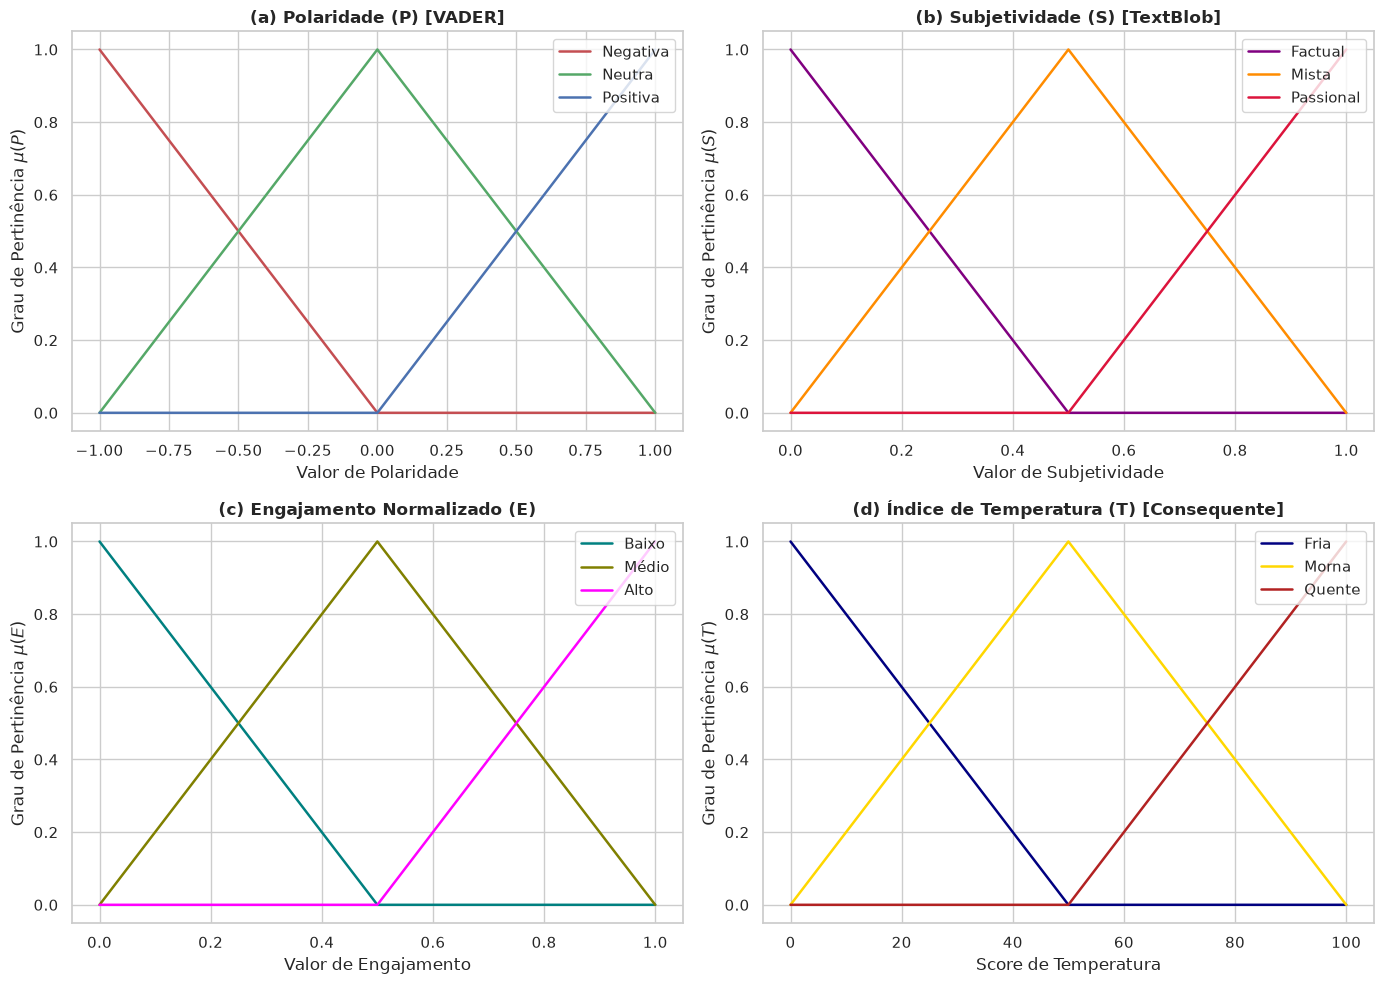

In [8]:
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# Polaridade
axs[0, 0].plot(univ_polarity, fuzz.trimf(univ_polarity, [-1.0, -1.0, 0.0]), 'r', linewidth=1.8, label='Negativa')
axs[0, 0].plot(univ_polarity, fuzz.trimf(univ_polarity, [-1.0, 0.0, 1.0]), 'g', linewidth=1.8, label='Neutra')
axs[0, 0].plot(univ_polarity, fuzz.trimf(univ_polarity, [0.0, 1.0, 1.0]), 'b', linewidth=1.8, label='Positiva')
axs[0, 0].set_title('(a) Polaridade (P) [VADER]', fontsize=12, fontweight='bold')
axs[0, 0].set_ylabel('Grau de Pertinência $\mu(P)$')
axs[0, 0].set_xlabel('Valor de Polaridade')
axs[0, 0].legend(loc='upper right')

# Subjetividade
axs[0, 1].plot(univ_subjectivity, fuzz.trimf(univ_subjectivity, [0.0, 0.0, 0.5]), 'purple', linewidth=1.8, label='Factual')
axs[0, 1].plot(univ_subjectivity, fuzz.trimf(univ_subjectivity, [0.0, 0.5, 1.0]), 'darkorange', linewidth=1.8, label='Mista')
axs[0, 1].plot(univ_subjectivity, fuzz.trimf(univ_subjectivity, [0.5, 1.0, 1.0]), 'crimson', linewidth=1.8, label='Passional')
axs[0, 1].set_title('(b) Subjetividade (S) [TextBlob]', fontsize=12, fontweight='bold')
axs[0, 1].set_ylabel('Grau de Pertinência $\mu(S)$')
axs[0, 1].set_xlabel('Valor de Subjetividade')
axs[0, 1].legend(loc='upper right')

# Engajamento
axs[1, 0].plot(univ_engagement, fuzz.trimf(univ_engagement, [0.0, 0.0, 0.5]), 'teal', linewidth=1.8, label='Baixo')
axs[1, 0].plot(univ_engagement, fuzz.trimf(univ_engagement, [0.0, 0.5, 1.0]), 'olive', linewidth=1.8, label='Médio')
axs[1, 0].plot(univ_engagement, fuzz.trimf(univ_engagement, [0.5, 1.0, 1.0]), 'magenta', linewidth=1.8, label='Alto')
axs[1, 0].set_title('(c) Engajamento Normalizado (E)', fontsize=12, fontweight='bold')
axs[1, 0].set_ylabel('Grau de Pertinência $\mu(E)$')
axs[1, 0].set_xlabel('Valor de Engajamento')
axs[1, 0].legend(loc='upper right')

# Temperatura
axs[1, 1].plot(univ_temperature, fuzz.trimf(univ_temperature, [0.0, 0.0, 50.0]), 'navy', linewidth=1.8, label='Fria')
axs[1, 1].plot(univ_temperature, fuzz.trimf(univ_temperature, [0.0, 50.0, 100.0]), 'gold', linewidth=1.8, label='Morna')
axs[1, 1].plot(univ_temperature, fuzz.trimf(univ_temperature, [50.0, 100.0, 100.0]), 'firebrick', linewidth=1.8, label='Quente')
axs[1, 1].set_title('(d) Índice de Temperatura (T) [Consequente]', fontsize=12, fontweight='bold')
axs[1, 1].set_ylabel('Grau de Pertinência $\mu(T)$')
axs[1, 1].set_xlabel('Score de Temperatura')
axs[1, 1].legend(loc='upper right')

plt.tight_layout()
for d in ['../figures', 'figures']:
    if os.path.exists(d):
        fig.savefig(f'{d}/funcoes_pertinencia.png', dpi=300)
plt.show()

## 5. Construção da Base de 27 Regras Mamdani

Registramos exaustivamente as $3 \times 3 \times 3 = 27$ regras de inferência.

In [9]:
rules = [
    # --- Engajamento Baixo (Repercussão nula ou individual) ---
    ctrl.Rule(polarity['negativa'] & subjectivity['factual'] & engagement['baixo'], temperature['fria']),   # R01
    ctrl.Rule(polarity['negativa'] & subjectivity['mista'] & engagement['baixo'], temperature['fria']),     # R02
    ctrl.Rule(polarity['negativa'] & subjectivity['passional'] & engagement['baixo'], temperature['morna']), # R03
    ctrl.Rule(polarity['neutra'] & subjectivity['factual'] & engagement['baixo'], temperature['fria']),      # R04
    ctrl.Rule(polarity['neutra'] & subjectivity['mista'] & engagement['baixo'], temperature['fria']),        # R05
    ctrl.Rule(polarity['neutra'] & subjectivity['passional'] & engagement['baixo'], temperature['fria']),    # R06
    ctrl.Rule(polarity['positiva'] & subjectivity['factual'] & engagement['baixo'], temperature['fria']),    # R07
    ctrl.Rule(polarity['positiva'] & subjectivity['mista'] & engagement['baixo'], temperature['fria']),      # R08
    ctrl.Rule(polarity['positiva'] & subjectivity['passional'] & engagement['baixo'], temperature['morna']), # R09

    # --- Engajamento Médio (Tração moderada, repercussão de nicho) ---
    ctrl.Rule(polarity['negativa'] & subjectivity['factual'] & engagement['medio'], temperature['morna']),   # R10
    ctrl.Rule(polarity['negativa'] & subjectivity['mista'] & engagement['medio'], temperature['morna']),     # R11
    ctrl.Rule(polarity['negativa'] & subjectivity['passional'] & engagement['medio'], temperature['quente']),# R12
    ctrl.Rule(polarity['neutra'] & subjectivity['factual'] & engagement['medio'], temperature['fria']),      # R13
    ctrl.Rule(polarity['neutra'] & subjectivity['mista'] & engagement['medio'], temperature['morna']),      # R14
    ctrl.Rule(polarity['neutra'] & subjectivity['passional'] & engagement['medio'], temperature['morna']),  # R15
    ctrl.Rule(polarity['positiva'] & subjectivity['factual'] & engagement['medio'], temperature['fria']),    # R16
    ctrl.Rule(polarity['positiva'] & subjectivity['mista'] & engagement['medio'], temperature['morna']),     # R17
    ctrl.Rule(polarity['positiva'] & subjectivity['passional'] & engagement['medio'], temperature['quente']),# R18

    # --- Engajamento Alto (Viralização e alcance massivo) ---
    ctrl.Rule(polarity['negativa'] & subjectivity['factual'] & engagement['alto'], temperature['morna']),    # R19
    ctrl.Rule(polarity['negativa'] & subjectivity['mista'] & engagement['alto'], temperature['quente']),     # R20
    ctrl.Rule(polarity['negativa'] & subjectivity['passional'] & engagement['alto'], temperature['quente']), # R21
    ctrl.Rule(polarity['neutra'] & subjectivity['factual'] & engagement['alto'], temperature['morna']),     # R22
    ctrl.Rule(polarity['neutra'] & subjectivity['mista'] & engagement['alto'], temperature['morna']),       # R23
    ctrl.Rule(polarity['neutra'] & subjectivity['passional'] & engagement['alto'], temperature['quente']),   # R24
    ctrl.Rule(polarity['positiva'] & subjectivity['factual'] & engagement['alto'], temperature['morna']),    # R25
    ctrl.Rule(polarity['positiva'] & subjectivity['mista'] & engagement['alto'], temperature['quente']),     # R26
    ctrl.Rule(polarity['positiva'] & subjectivity['passional'] & engagement['alto'], temperature['quente']), # R27
]

system_ctrl = ctrl.ControlSystem(rules)
print(f'Sistema montado com sucesso! Total de regras registradas: {len(rules)}')

Sistema montado com sucesso! Total de regras registradas: 27


## 6. Superfícies de Controle 3D (*Control Surfaces*)

A superfície de controle demonstra a transição suave e não-linear do modelo difuso, comprovando que o sistema não depende de limiares rígidos.

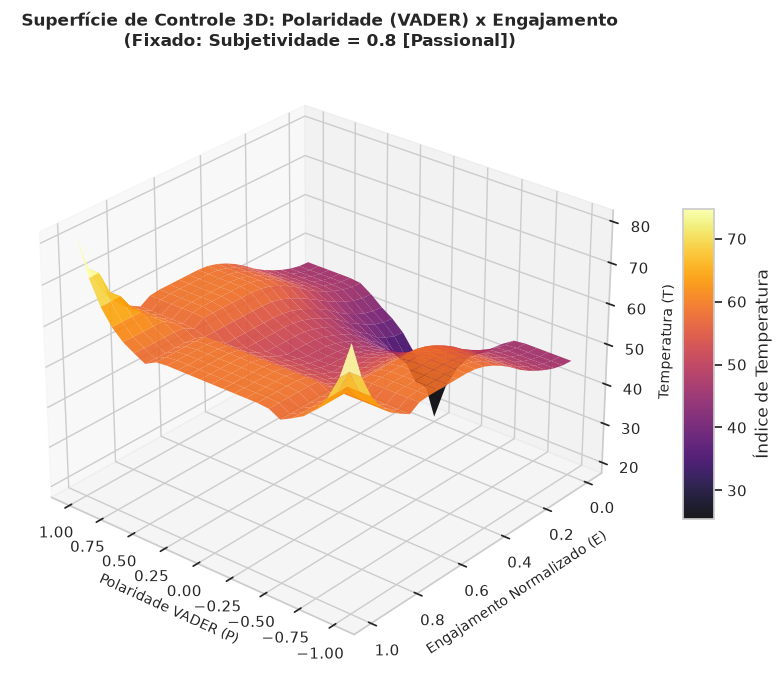

In [10]:
def evaluate_fuzzy(p_in, s_in, e_in):
    sim = ctrl.ControlSystemSimulation(system_ctrl)
    sim.input['polarity'] = float(np.clip(p_in, -1.0, 1.0))
    sim.input['subjectivity'] = float(np.clip(s_in, 0.0, 1.0))
    sim.input['engagement'] = float(np.clip(e_in, 0.0, 1.0))
    try:
        sim.compute()
        return sim.output['temperature']
    except Exception:
        return 50.0

# Grade de pontos para superfície 3D (Polaridade x Engajamento, Subjetividade fixa em 0.8)
p_grid = np.linspace(-1.0, 1.0, 25)
e_grid = np.linspace(0.0, 1.0, 25)
P_mesh, E_mesh = np.meshgrid(p_grid, e_grid)
T_mesh = np.zeros_like(P_mesh)

for r in range(P_mesh.shape[0]):
    for c in range(P_mesh.shape[1]):
        T_mesh[r, c] = evaluate_fuzzy(P_mesh[r, c], 0.8, E_mesh[r, c])

fig = plt.figure(figsize=(11, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(P_mesh, E_mesh, T_mesh, cmap='inferno', edgecolor='none', alpha=0.9)

ax.set_title('Superfície de Controle 3D: Polaridade (VADER) x Engajamento\n(Fixado: Subjetividade = 0.8 [Passional])', fontsize=12, fontweight='bold')
ax.set_xlabel('Polaridade VADER (P)', fontsize=10)
ax.set_ylabel('Engajamento Normalizado (E)', fontsize=10)
ax.set_zlabel('Temperatura (T)', fontsize=10)
ax.view_init(elev=28, azim=130)
cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
cbar.set_label('Índice de Temperatura')

plt.tight_layout()
for d in ['../figures', 'figures']:
    if os.path.exists(d):
        fig.savefig(f'{d}/superficie_controle_3d.png', dpi=300)
plt.show()

## 7. Aplicação no Dataset e Geração da Temperatura

Inferimos a temperatura de cada publicação do dataset e adicionamos a classificação qualitativa:
* **Fria:** $T < 35$
* **Morna:** $35 \le T < 65$
* **Quente:** $T \ge 65$

In [11]:
print('Processando inferência difusa para todas as linhas do dataset...')

temperaturas = []
for idx, row in df.iterrows():
    temp = evaluate_fuzzy(row['polarity'], row['subjectivity'], row['engagement'])
    temperaturas.append(temp)

df['Temperatura'] = temperaturas

# Classificação Linguística
def classificar_temperatura(t):
    if t < 35.0:
        return 'Fria'
    elif t < 65.0:
        return 'Morna'
    else:
        return 'Quente'

df['Classe_Temperatura'] = df['Temperatura'].apply(classificar_temperatura)

print('Inferência concluída com sucesso!')
df[['Text', 'Sentiment', 'Likes', 'Retweets', 'polarity', 'subjectivity', 'engagement', 'Temperatura', 'Classe_Temperatura']].head(10)

Processando inferência difusa para todas as linhas do dataset...
Inferência concluída com sucesso!


,Text,Sentiment,Likes,Retweets,polarity,subjectivity,engagement,Temperatura,Classe_Temperatura
0,Enjoying a beautiful day at the park!,Positive,30.0,15.0,0.8221,0.800000,0.521971,58.780488,Morna
1,Traffic was terrible this morning.,Negative,10.0,5.0,-0.4767,1.000000,0.000000,43.451257,Morna
2,Just finished an amazing workout! 💪,Positive,40.0,20.0,0.6239,0.900000,0.661469,59.570217,Morna
3,Excited about the upcoming weekend getaway!,Positive,15.0,8.0,0.4003,0.750000,0.200408,47.683388,Morna
4,Trying out a new recipe for dinner tonight.,Neutral,25.0,12.0,0.0000,0.454545,0.427539,49.494466,Morna
5,Feeling grateful for the little things in life.,Positive,50.0,25.0,0.5423,0.500000,0.770138,57.005744,Morna
6,Rainy days call for cozy blankets and hot cocoa.,Positive,20.0,10.0,-0.0772,0.800000,0.326907,47.225522,Morna
7,The new movie release is a must-watch!,Positive,30.0,15.0,0.0000,0.454545,0.521971,49.798631,Morna
8,Political discussions heating up on the timeline.,Negative,60.0,30.0,0.0000,0.100000,0.859168,48.128378,Morna
9,Missing summer vibes and beach days.,Neutral,35.0,18.0,-0.2960,0.050000,0.601223,37.795499,Morna


## 8. Validação e Análise Estatística Cruzada

Para validar o comportamento do modelo na ausência de ground truth contínuo, analisamos se postagens rotuladas com emoções intensas (*Anger, Joy, Surprise*) possuem distribuições de temperatura distintas daquelas associadas à neutralidade (*Neutral*).

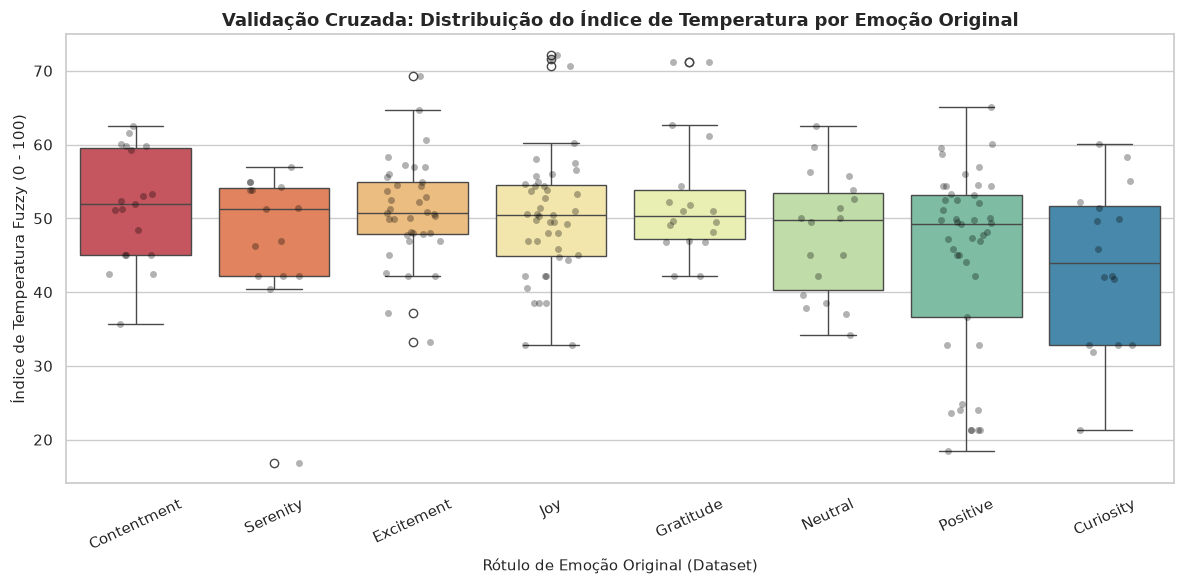

In [12]:
# Seleciona as emoções mais frequentes no dataset para visualização limpa
top_emocoes = df['Sentiment'].value_counts().head(8).index
df_filtrado = df[df['Sentiment'].isin(top_emocoes)]

fig, ax = plt.subplots(figsize=(12, 6))
order_medians = df_filtrado.groupby('Sentiment')['Temperatura'].median().sort_values(ascending=False).index

sns.boxplot(data=df_filtrado, x='Sentiment', y='Temperatura', order=order_medians, palette='Spectral', ax=ax)
sns.stripplot(data=df_filtrado, x='Sentiment', y='Temperatura', order=order_medians, color='black', alpha=0.3, jitter=0.2, ax=ax)

ax.set_title('Validação Cruzada: Distribuição do Índice de Temperatura por Emoção Original', fontsize=13, fontweight='bold')
ax.set_xlabel('Rótulo de Emoção Original (Dataset)', fontsize=11)
ax.set_ylabel('Índice de Temperatura Fuzzy (0 - 100)', fontsize=11)
plt.xticks(rotation=25)
plt.tight_layout()

for d in ['../figures', 'figures']:
    if os.path.exists(d):
        fig.savefig(f'{d}/boxplot_temperatura_emocoes.png', dpi=300)
plt.show()

### Casos Extremos: Top 5 Publicações Mais Quentes e Mais Frias

In [13]:
print('=== TOP 5 POSTAGENS MAIS QUENTES (MAIOR TEMPERATURA) ===')
top_quentes = df.sort_values(by='Temperatura', ascending=False)[['Text', 'Sentiment', 'Likes', 'Retweets', 'Temperatura', 'Classe_Temperatura']].head(5)
display(top_quentes)

print('\n=== TOP 5 POSTAGENS MAIS FRIAS (MENOR TEMPERATURA) ===')
top_frias = df.sort_values(by='Temperatura', ascending=True)[['Text', 'Sentiment', 'Likes', 'Retweets', 'Temperatura', 'Classe_Temperatura']].head(5)
display(top_frias)

=== TOP 5 POSTAGENS MAIS QUENTES (MAIOR TEMPERATURA) ===


,Text,Sentiment,Likes,Retweets,Temperatura,Classe_Temperatura
355,Anticipation for an upcoming adventure in an e...,Anticipation,80.0,40.0,81.413039,Quente
322,"Fearful eyes scanning the shadows, a prisoner ...",Fearful,36.0,18.0,76.215323,Quente
495,"In the embrace of the Grand Canyon, nature's m...",Awe,50.0,25.0,73.662847,Quente
481,"Surrounded by the colors of joy, a canvas pain...",Joy,80.0,40.0,72.174077,Quente
262,"Gratitude as a guiding star, navigating the co...",Grateful,38.0,19.0,71.760584,Quente



=== TOP 5 POSTAGENS MAIS FRIAS (MENOR TEMPERATURA) ===


,Text,Sentiment,Likes,Retweets,Temperatura,Classe_Temperatura
259,"Lost in the symphony of the night, a moonlit s...",Serenity,26.0,13.0,16.826083,Fria
220,A melancholic symphony playing in the backgrou...,Melancholy,26.0,13.0,16.908747,Fria
294,"Embraced by the hopeful dawn, a gardener sowin...",Hopeful,28.0,14.0,16.970733,Fria
280,"Embraced by the hopeful dawn, a gardener sowin...",Hopeful,28.0,14.0,16.970733,Fria
266,"Embraced by the hopeful dawn, a gardener sowin...",Hopeful,28.0,14.0,16.970733,Fria
